In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
# Loading the file 
car_accidents_df = pd.read_csv('C:/Users/andre/OneDrive/Desktop/Boolean/Final Project/car_accidents.csv')

C:\Users\andre\AppData\Local\Temp\ipykernel_11320\780528760.py:2: DtypeWarning: Columns (0: Comune (dizione straniera)) have mixed types. Specify dtype option on import or set low_memory=False.
  car_accidents_df = pd.read_csv('C:/Users/andre/OneDrive/Desktop/Boolean/Final Project/car_accidents.csv')


In [13]:
# Lookig for NaN values
car_accidents_df['Comune'].isna().sum()

np.int64(24939)

In [14]:
car_accidents_df.shape

(573552, 23)

- There 573552 total rows, 24939 (4,35%) of these have 'Comune' column as NaN. I'll keep these NaN values for the first overall analysis and exclude them when I will analyze each Comune name

In [15]:
# Understanding how mani accidents per REF_AREA with Comune as NaN
car_accidents_df[car_accidents_df['Comune'].isna()].groupby(['REF_AREA', 'OBS_VALUE']).size().reset_index().sort_values(by=0, ascending=False)

,REF_AREA,OBS_VALUE,0
124,6064,0,55
5378,96062,0,54
5549,103030,0,54
41,1277,0,52
5445,97081,0,51
...,...,...,...
30,1168,19,1
24,1168,10,1
454,15017,25,1
451,15017,20,1


Understanding the data: 

- DATA_TYPE has 'KILLINJ' OR 'ROADACC' VALUES: KILLINJ = Killed and injured - ROADACC = Road accidents

- RESULT has F, M OR 9 VALUES: F = Feriti, M = Morti, 9 = Accidents without injuries and deads

- OBS_VALUE = Num of observations

In [ ]:
road_accidents = car_accidents_df[car_accidents_df['DATA_TYPE'] == 'ROADACC'].groupby('TIME_PERIOD')['OBS_VALUE'].sum().reset_index()

kill_or_inj = car_accidents_df[car_accidents_df['DATA_TYPE'] == 'KILLINJ'].groupby('TIME_PERIOD')['OBS_VALUE'].sum().reset_index()

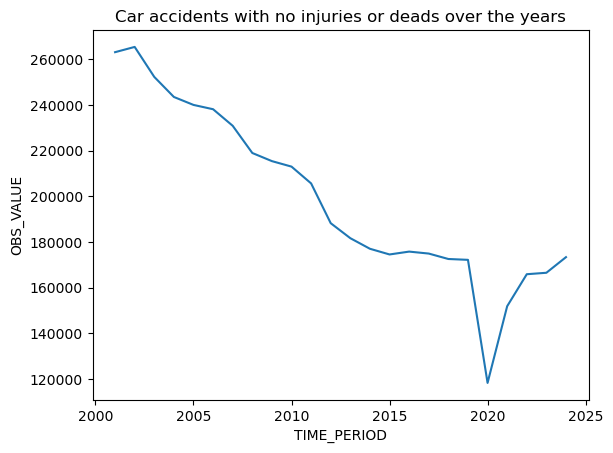

In [17]:
sns.lineplot(x = 'TIME_PERIOD', y = 'OBS_VALUE', data = road_accidents)
plt.title('Car accidents with no injuries or deads over the years')
plt.show()

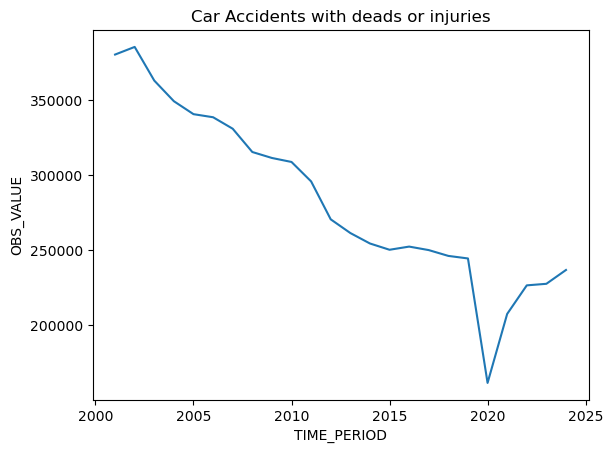

In [18]:
sns.lineplot(x = 'TIME_PERIOD', y = 'OBS_VALUE', data = kill_or_inj)
plt.title('Car Accidents with deads or injuries')
plt.show()

In [19]:
injuries = car_accidents_df[(car_accidents_df['DATA_TYPE'] == 'KILLINJ') & (car_accidents_df['RESULT'] == 'F')].groupby('TIME_PERIOD')['OBS_VALUE'].sum().reset_index()

kills = car_accidents_df[(car_accidents_df['DATA_TYPE'] == 'KILLINJ') & (car_accidents_df['RESULT'] == 'M')].groupby('TIME_PERIOD')['OBS_VALUE'].sum().reset_index()

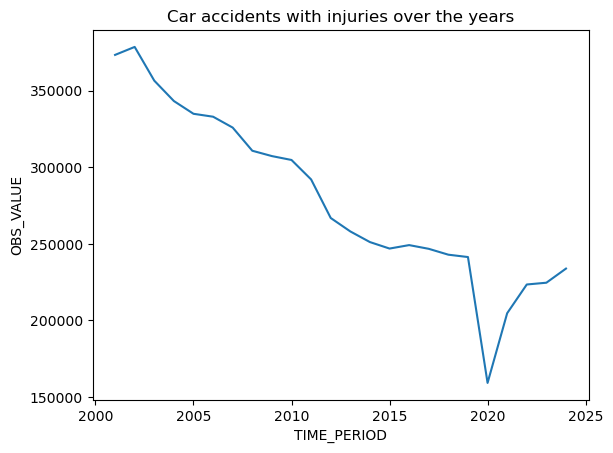

In [20]:
sns.lineplot(x = 'TIME_PERIOD', y = 'OBS_VALUE', data = injuries)
plt.title('Car accidents with injuries over the years')
plt.show()

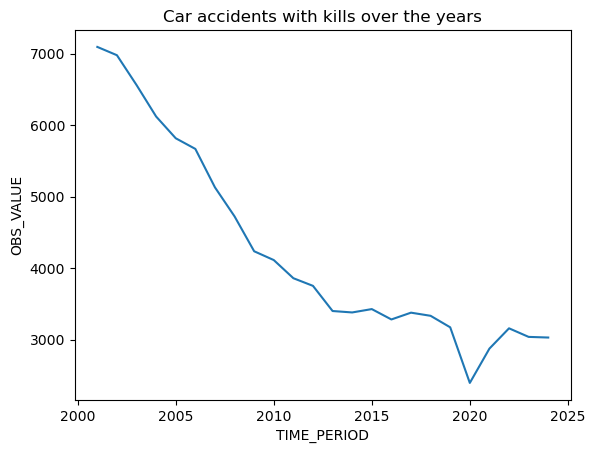

In [21]:
sns.lineplot(x = 'TIME_PERIOD', y = 'OBS_VALUE', data = kills)
plt.title('Car accidents with kills over the years')
plt.show()

In [22]:
car_accidents_df.groupby(['Comune'])['OBS_VALUE'].sum().sort_values(ascending=False).reset_index().head(10)

,Comune,OBS_VALUE
0,Roma,901300
1,Milano,629964
2,Genova,231413
3,Torino,217874
4,Firenze,165301
5,Napoli,145248
6,Palermo,128656
7,Bologna,124514
8,Bari,111232
9,Verona,83891


In [23]:
car_accidents_df[car_accidents_df['DATA_TYPE'] == 'KILLINJ'].groupby(['Comune'])['OBS_VALUE'].sum().sort_values(ascending=False).head(10)

Comune
Roma       510695
Milano     357419
Torino     130647
Genova     128719
Firenze     90764
Napoli      84517
Palermo     74626
Bologna     70656
Bari        67060
Catania     48492
Name: OBS_VALUE, dtype: int64

In [30]:
kills_and_injuries_per_comune = car_accidents_df[car_accidents_df['DATA_TYPE'] == 'KILLINJ'].groupby(['Comune', 'TIME_PERIOD', 'Popolazione residente', 'Superficie (Kmq)'])['OBS_VALUE'].sum().reset_index()

In [31]:
# Excluding data without car accidents
kills_and_injuries_per_comune = kills_and_injuries_per_comune[kills_and_injuries_per_comune['OBS_VALUE'] > 0]

In [32]:
kills_and_injuries_per_comune['ratio_based_on_population'] = round(kills_and_injuries_per_comune['OBS_VALUE'] / kills_and_injuries_per_comune['Popolazione residente'],2)

In [33]:
kills_and_injuries_per_comune['ratio_based_on_area'] = round(kills_and_injuries_per_comune['OBS_VALUE'] / kills_and_injuries_per_comune['Superficie (Kmq)'],2)

In [34]:
kills_and_injuries_per_comune[['Comune', 'OBS_VALUE', 'Popolazione residente' ,'ratio_based_on_population', 'TIME_PERIOD']].sort_values(by='ratio_based_on_population', ascending=False).head(20)

,Comune,OBS_VALUE,Popolazione residente,ratio_based_on_population,TIME_PERIOD
2532,Albaredo per San Marco,83,288.0,0.29,2001
137324,Salasco,54,201.0,0.27,2007
39332,Castelmagno,9,59.0,0.15,2020
94823,Moncenisio,5,41.0,0.12,2022
21088,Briga Alta,5,41.0,0.12,2017
13632,Belforte Monferrato,61,502.0,0.12,2001
172661,Vallepietra,30,251.0,0.12,2009
138299,Sambuco,9,85.0,0.11,2015
114858,Perarolo di Cadore,37,367.0,0.10,2009
172657,Vallepietra,25,251.0,0.10,2005


In [36]:
kills_and_injuries_per_comune[['Comune', 'OBS_VALUE', 'Superficie (Kmq)' ,'ratio_based_on_area' , 'TIME_PERIOD']].sort_values(by='ratio_based_on_area').head(20)

,Comune,OBS_VALUE,Superficie (Kmq),ratio_based_on_area,TIME_PERIOD
31924,Caronia,1,227.2587,0.0,2002
76522,Irsina,1,263.4530,0.0,2004
83024,Longobucco,1,212.2541,0.0,2021
83005,Longobucco,1,212.2541,0.0,2002
163997,Teulada,1,246.1839,0.0,2020
164001,Teulada,1,246.1839,0.0,2024
16369,Bitti,1,215.3679,0.0,2009
16379,Bitti,1,215.3679,0.0,2019
57277,Curon Venosta/Graun im Vinschgau,1,209.6475,0.0,2008
16378,Bitti,1,215.3679,0.0,2018


In [37]:
# Creating a new df considering only last 5 years
kills_and_injuries_per_comune_last_years = kills_and_injuries_per_comune[kills_and_injuries_per_comune['TIME_PERIOD']>= 2019]